## CP1 - Прогнозирование пожизненной ценности клиента (CLV)

**Задача:** Регрессия  Прогнозирование пожизненной ценности клиента (CLV)

**Датасет:** Kaggle - Ecommerce Customer Behavior Dataset (50000 строк, 24 признака)

**Структура ноутбука:**
- Блок 1: Импорты и настройки
- Блок 2: Загрузка данных и первичный осмотр
- Блок 3: Полная очистка данных (пропуски, дубликаты, выбросы, типы)
- Блок 4: Feature Engineering (создание новых признаков)
- Блок 5: Удаление NaN (если остались) + сплит train/val/test
- Блок 6: Определение метрик и функции оценки
- Блок 7: Визуализации зависимостей (до обучения моделей)
- Блок 8: Моделирование (Baseline + улучшенные модели)
- Блок 9: Таблица результатов и выбор лучшей модели

#### Обоснование выбора датасета

Датасет взят с Kaggle: [https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset]. Содержит 24 признака, включая демографию (Age, Gender, Country, City), поведенческие метрики (Session_Duration_Avg, Cart_Abandonment_Rate, Total_Purchases и др.) и итоговую целевую переменную Lifetime_Value — суммарную денежную ценность клиента за всё время. Задача — регрессия: предсказать Lifetime_Value по остальным признакам. Датасет подходит для обучения моделей прогнозирования CLV.

### Блок 1: Импорты и настройки

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Блок 2: Загрузка данных и первичный осмотр

In [2]:
file_path = "../data/raw/ecommerce_customer_churn_dataset.csv"

df = pd.read_csv(file_path)
df = df.copy()

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов\n")
print("Первые 5 строк:")
df.head()

Размер датасета: 50000 строк, 25 столбцов

Первые 5 строк:


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
print("Типы данных и пропуски:")
df.info()

Типы данных и пропуски:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47

In [4]:
print("Основные статистики числовых признаков:")
df.describe()

Основные статистики числовых признаков:


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


### Блок 3: Полная очистка данных (пропуски, дубликаты, выбросы, типы)

Пропуски по столбцам:
Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64
Пропуски обрабо

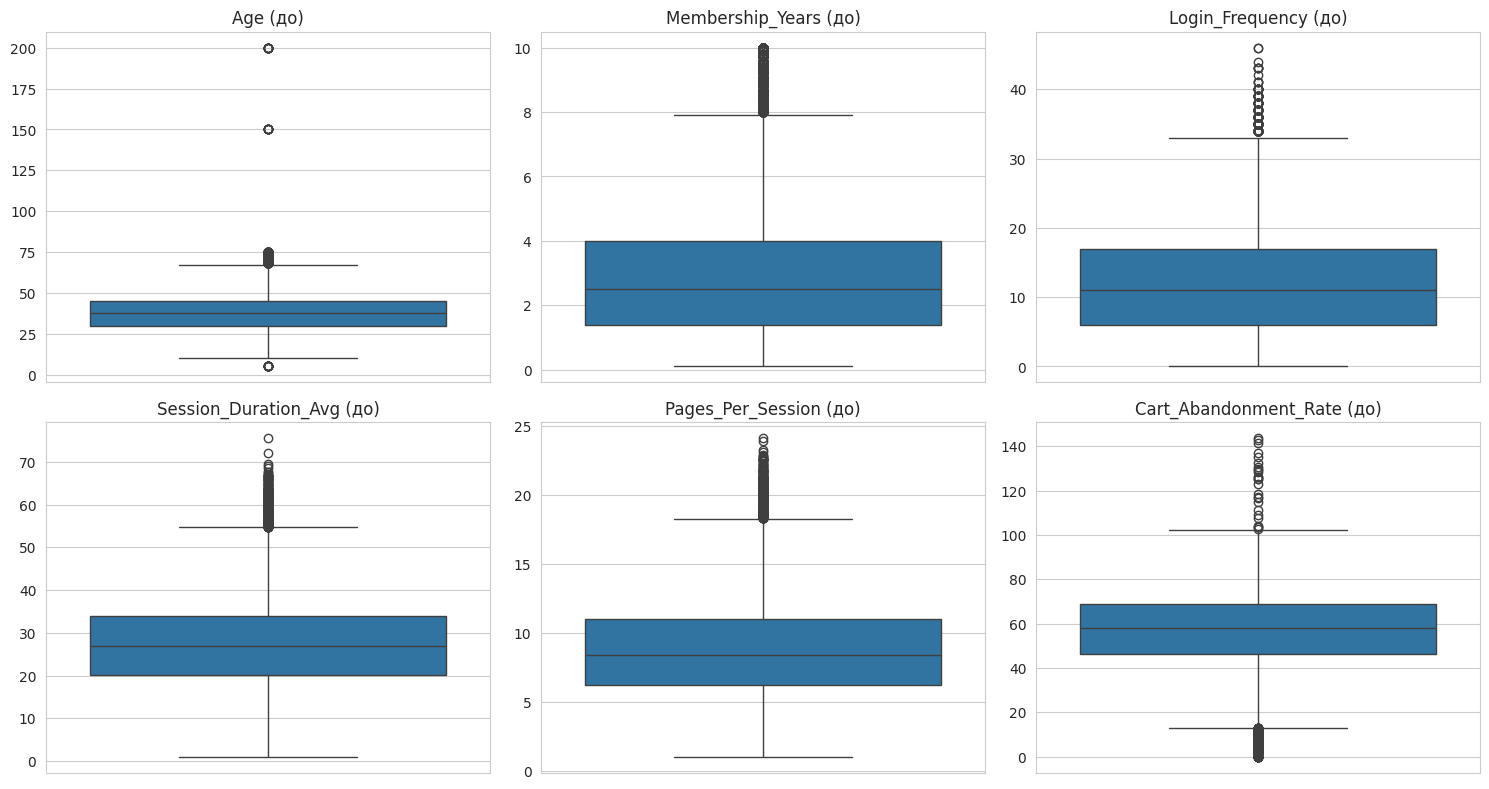

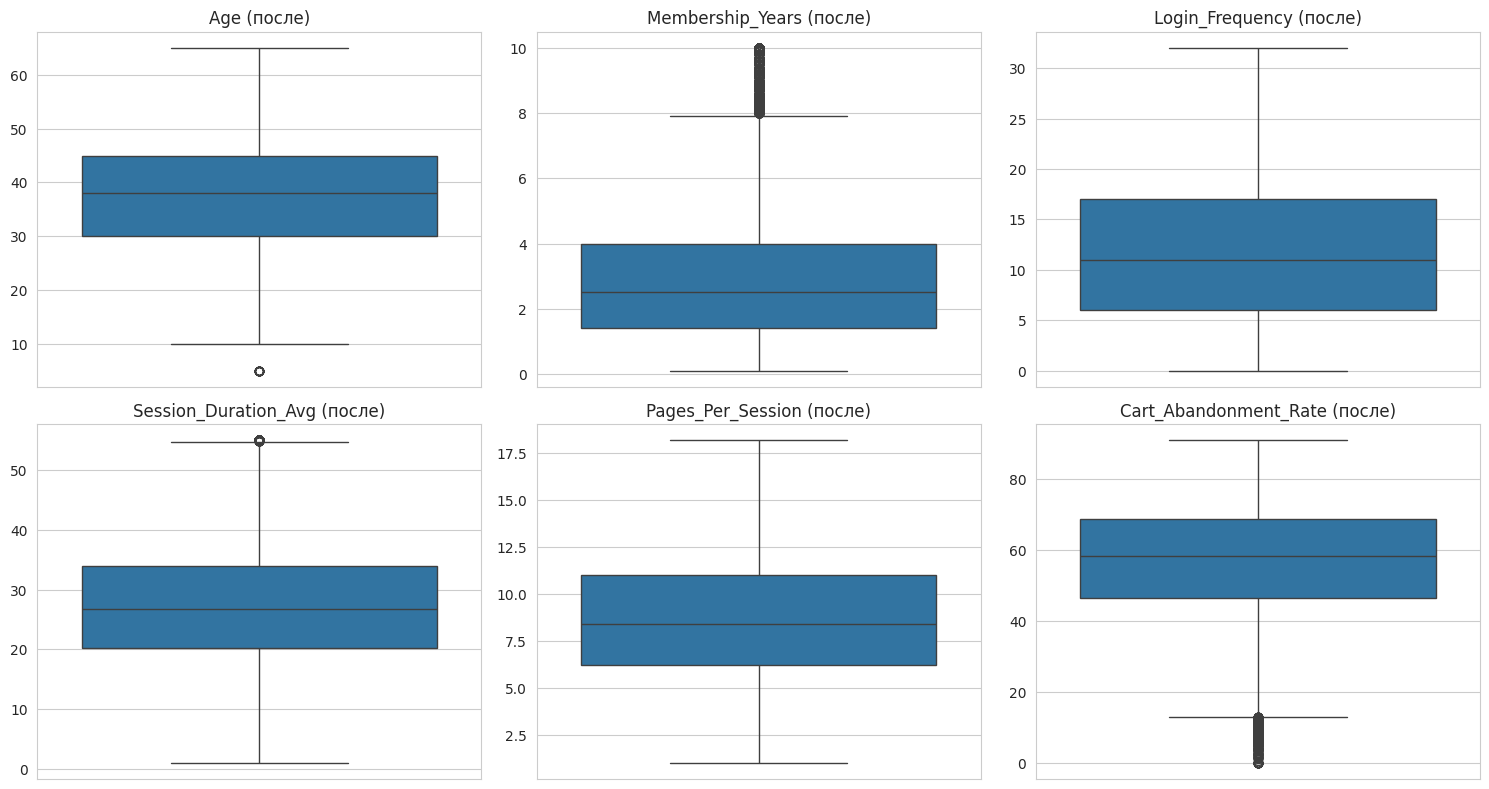

Выбросы ограничены 99-м перцентилем.


In [ ]:
print("Пропуски по столбцам:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
print("Пропуски обработаны.")

duplicates = df.duplicated().sum()
print(f"Дубликаты строк: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Дубликаты удалены.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Lifetime_Value' in numeric_cols:
    numeric_cols.remove('Lifetime_Value')

continuous_cols = [col for col in numeric_cols if df[col].nunique() >= 10]
print("Непрерывные признаки для анализа выбросов:", continuous_cols[:8])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_cols[:6]):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"{col} (до)")
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()

for col in continuous_cols:
    cap = df[col].quantile(0.99)
    df[col] = np.where(df[col] > cap, cap, df[col])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_cols[:6]):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"{col} (после)")
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()
print("Выбросы ограничены 99-м перцентилем.")

categorical_cols = ['Gender', 'Country', 'City', 'Signup_Quarter', 'Churned']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

### Блок 4: Feature Engineering (создание новых признаков)

In [ ]:
target = 'Lifetime_Value'

if 'Customer_ID' in df.columns:
    X_raw = df.drop(columns=[target, 'Customer_ID'])
else:
    X_raw = df.drop(columns=[target])
y = df[target].copy()

original_features = X_raw.columns.tolist()
print(f"Исходное количество признаков: {len(original_features)}")

X = X_raw.copy()

if 'Login_Frequency' in X.columns and 'Session_Duration_Avg' in X.columns:
    X['Login_Session_Product'] = X['Login_Frequency'] * X['Session_Duration_Avg']

if 'Days_Since_Last_Purchase' in X.columns:
    X['Recency_Score'] = 1 / (X['Days_Since_Last_Purchase'] + 1)

if 'Product_Reviews_Written' in X.columns and 'Social_Media_Engagement_Score' in X.columns:
    X['Engagement_Index'] = X['Product_Reviews_Written'] + X['Social_Media_Engagement_Score']

if 'Returns_Rate' in X.columns and 'Total_Purchases' in X.columns:
    X['Returns_Per_Purchase'] = X['Returns_Rate'] / (X['Total_Purchases'] + 1)

if 'Age' in X.columns:
    X['Age_Group'] = pd.cut(X['Age'], bins=[0, 25, 35, 50, 100], labels=['Young', 'Adult', 'Middle', 'Senior'])

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print("Закодированы категориальные столбцы:", cat_cols)

print(f"После feature engineering: {X.shape[1]} признаков (добавлено {X.shape[1] - len(original_features)})")
print("Новые признаки (примеры):")
new_feats = set(X.columns) - set(original_features)
for f in sorted(new_feats)[:10]:
    print(f"  - {f}")
if len(new_feats) > 10:
    print(f"  ... и ещё {len(new_feats)-10}")

Исходное количество признаков: 24
Закодированы категориальные столбцы: ['Gender', 'Country', 'City', 'Churned', 'Signup_Quarter', 'Age_Group']
После feature engineering: 78 признаков (добавлено 54)
Новые признаки (примеры):
  - Age_Group_Adult
  - Age_Group_Middle
  - Age_Group_Senior
  - Churned_1
  - City_Bangalore
  - City_Berlin
  - City_Birmingham
  - City_Brisbane
  - City_Calgary
  - City_Chennai
  ... и ещё 49


### Блок 5: Удаление NaN (если остались) + сплит train/val/test

In [ ]:
nan_before = X.isna().any(axis=1).sum()
if nan_before > 0:
    print(f"Найдено {nan_before} строк с NaN. Удаляем...")
    X = X.dropna()
    y = y[X.index]
print(f"NaN в X после очистки: {X.isna().any().any()}, в y: {y.isna().any()}")

inf_mask = np.isinf(X).any(axis=1)
if inf_mask.any():
    print(f"Найдено {inf_mask.sum()} строк с inf. Удаляем...")
    X = X[~inf_mask]
    y = y[~inf_mask]
print(f"Inf в X после очистки: {np.isinf(X).any().any()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=SEED)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

NaN в X после очистки: False, в y: False
Найдено 2 строк с inf. Удаляем...
Inf в X после очистки: False
Train: 34997 samples
Validation: 7501 samples
Test: 7500 samples


### Блок 6: Определение метрик и функции оценки

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"{model_name:45} | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | R2: {r2:.4f}")
    return {'name': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print("Используемые метрики:\n- RMSE (основная, чувствительна к большим ошибкам)\n- MAE (средняя абсолютная)\n- R2 (доля объяснённой дисперсии)")

Используемые метрики:
- RMSE (основная, чувствительна к большим ошибкам)
- MAE (средняя абсолютная)
- R2 (доля объяснённой дисперсии)


### Блок 7: Визуализации зависимостей (до обучения моделей)

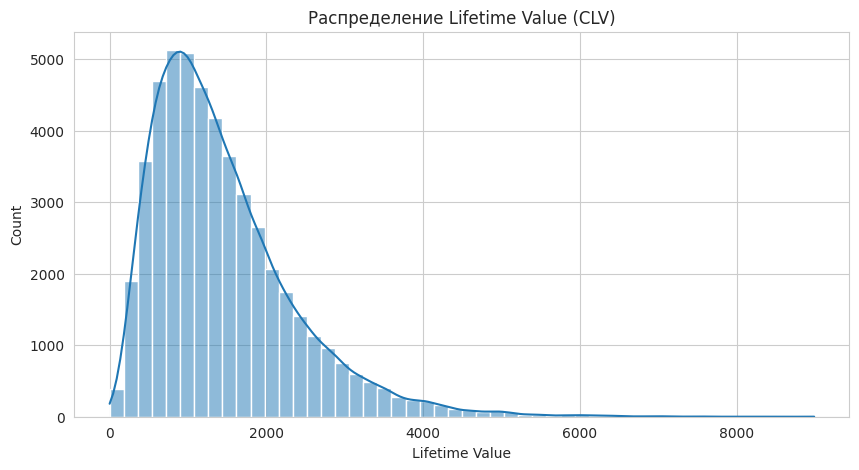

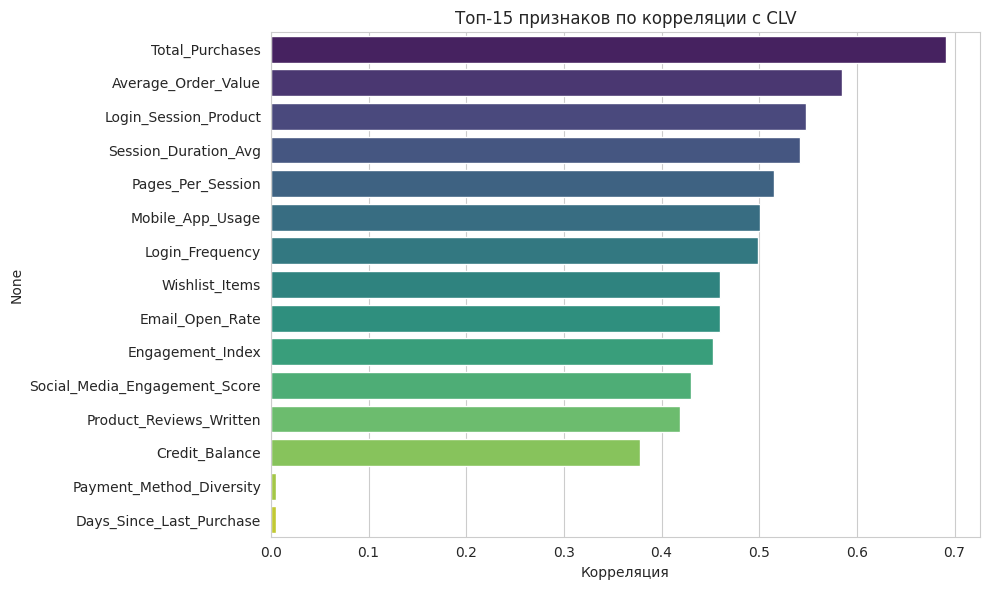

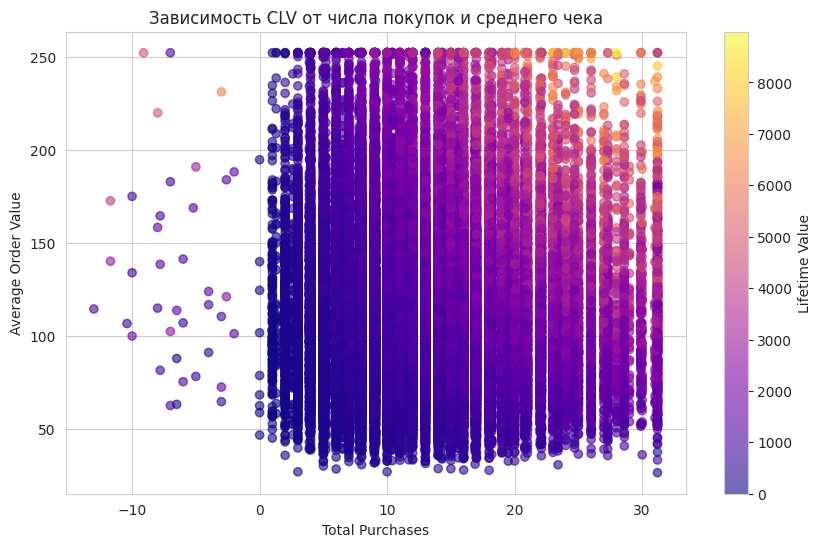

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Распределение Lifetime Value (CLV)")
plt.xlabel("Lifetime Value")
plt.show()

X_num = X.select_dtypes(include=[np.number])
corr_with_target = X_num.corrwith(y).sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, 
            hue=corr_with_target.index, palette='viridis', legend=False)
plt.title("Топ-15 признаков по корреляции с CLV")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.show()

if 'Total_Purchases' in X.columns and 'Average_Order_Value' in X.columns:
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X['Total_Purchases'], X['Average_Order_Value'], c=y, cmap='plasma', alpha=0.6)
    plt.colorbar(sc, label='Lifetime Value')
    plt.xlabel('Total Purchases')
    plt.ylabel('Average Order Value')
    plt.title("Зависимость CLV от числа покупок и среднего чека")
    plt.show()

### Блок 8: Моделирование (Baseline + улучшенные модели)

In [ ]:
results = []

X_raw_encoded = pd.get_dummies(X_raw, drop_first=True)
X_raw_encoded = X_raw_encoded.loc[y.index]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_raw_encoded, y, test_size=0.15, random_state=SEED)
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train_base, y_train_base, test_size=0.1765, random_state=SEED)

baseline_lr = LinearRegression()
results.append(evaluate_model(baseline_lr, X_train_base, y_train_base,
                              X_val_base, y_val_base,
                              "Baseline (Linear Regression, исходные признаки)"))

lr_full = LinearRegression()
results.append(evaluate_model(lr_full, X_train, y_train, X_val, y_val,
                              "Linear Regression (все признаки)"))

ridge = Ridge(alpha=1.0, random_state=SEED)
results.append(evaluate_model(ridge, X_train, y_train, X_val, y_val,
                              "Ridge Regression (alpha=1.0)"))

lasso = Lasso(alpha=1.0, random_state=SEED)
results.append(evaluate_model(lasso, X_train, y_train, X_val, y_val,
                              "Lasso Regression (alpha=1.0)"))

rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
results.append(evaluate_model(rf, X_train, y_train, X_val, y_val,
                              "Random Forest (n=100)"))

rf_small = RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1)
results.append(evaluate_model(rf_small, X_train, y_train, X_val, y_val,
                              "Random Forest (n=50)"))

Baseline (Linear Regression, исходные признаки) | RMSE:   350.23 | MAE:   236.26 | R2: 0.8531
Linear Regression (все признаки)              | RMSE:   348.02 | MAE:   235.34 | R2: 0.8549
Ridge Regression (alpha=1.0)                  | RMSE:   348.02 | MAE:   235.34 | R2: 0.8549
Lasso Regression (alpha=1.0)                  | RMSE:   348.07 | MAE:   235.17 | R2: 0.8549
Random Forest (n=100)                         | RMSE:   233.56 | MAE:   153.86 | R2: 0.9347
Random Forest (n=50)                          | RMSE:   235.10 | MAE:   154.88 | R2: 0.9338


### Блок 9: Таблица результатов и выбор лучшей модели


=== СРАВНЕНИЕ МОДЕЛЕЙ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ ===
                                           name       RMSE        MAE       R2
Baseline (Linear Regression, исходные признаки) 350.229318 236.260340 0.853072
               Linear Regression (все признаки) 348.017342 235.339268 0.854922
                   Ridge Regression (alpha=1.0) 348.016757 235.338040 0.854922
                   Lasso Regression (alpha=1.0) 348.066022 235.174716 0.854881
                          Random Forest (n=100) 233.555087 153.861085 0.934660
                           Random Forest (n=50) 235.097907 154.879310 0.933794


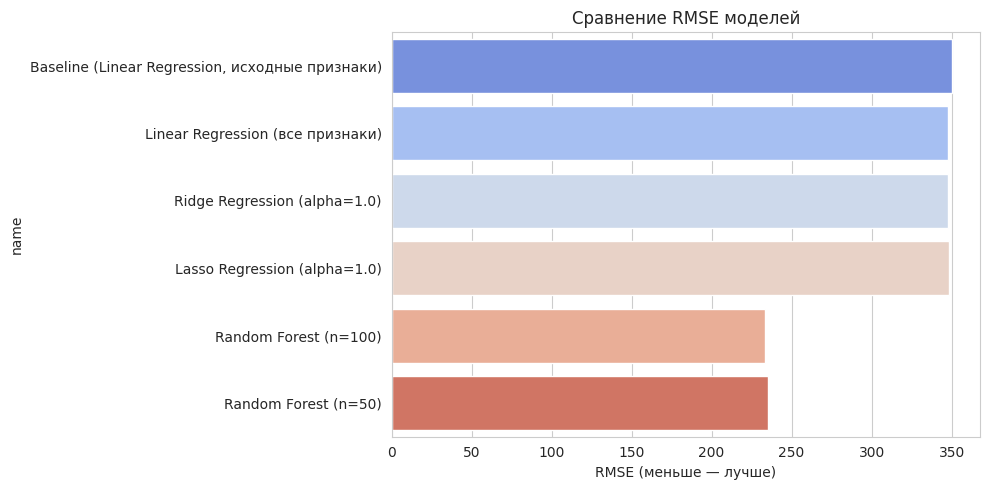


Лучшая модель по RMSE: Random Forest (n=100)
  RMSE: 233.56
  MAE:  153.86
  R2:   0.9347

=== ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
RMSE: 234.34, MAE: 155.29, R2: 0.9361


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df[['name', 'RMSE', 'MAE', 'R2']]
print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='RMSE', y='name', hue='name', palette='coolwarm', legend=False)
plt.xlabel("RMSE (меньше — лучше)")
plt.title("Сравнение RMSE моделей")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\nЛучшая модель по RMSE: {best_row['name']}")
print(f"  RMSE: {best_row['RMSE']:.2f}")
print(f"  MAE:  {best_row['MAE']:.2f}")
print(f"  R2:   {best_row['R2']:.4f}")

if best_row['name'] == "Baseline (Linear Regression, исходные признаки)":
    best_model = baseline_lr
elif best_row['name'] == "Linear Regression (все признаки)":
    best_model = lr_full
elif best_row['name'] == "Ridge Regression (alpha=1.0)":
    best_model = ridge
elif best_row['name'] == "Lasso Regression (alpha=1.0)":
    best_model = lasso
elif best_row['name'] == "Random Forest (n=100)":
    best_model = rf
else:
    best_model = rf_small

best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"\n=== ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(f"RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.4f}")